# Validate Slot Mapping — Visual Inspection

Notebook giúp ông validate `PT_TO_SLOT` trong [src/scripts/outfit_slots.py](../src/scripts/outfit_slots.py) bằng cách XEM ẢNH thật, không cần đọc 113 PT một-một.

**Cách dùng**:
1. Section 1: pick từng slot, random sample 8-12 items → mắt thấy item có hợp slot không.
2. Section 2: pick các PT "đáng ngờ" (Cardigan, Bodysuit, Tailored Waistcoat, Garment Set, Sarong, Costumes) → xem ảnh thật trong dataset có giống fashion concept thông thường không.
3. Section 3: pick một slot pair (vd. top+bottom) → sample các pair từ graph có thật → xem có phối hợp lý không.
4. Section 4: "other" slot (đang bị loại khỏi graph) — confirm các items này thực sự không phải fashion.

**Mỗi rerun không fix seed → sample mới**. Đặt `SEED = <int>` nếu muốn reproducible cho thesis figure.

Graph hiện tại: [data/processed/final_outfit_graph.csv](../data/processed/final_outfit_graph.csv) (cobuy_full_redesigned, 28K nodes, 303K edges, intra_PT=0%).

## Setup (chạy 1 lần)

In [1]:
import os
import random
import sys
from collections import Counter
from pathlib import Path
from typing import Dict, List, Optional, Tuple

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from src.backend.core.config import settings
from src.backend.services.catalog import FashionCatalog
from src.scripts.outfit_slots import PT_TO_SLOT, PG_TO_SLOT, GG_TO_SLOT, ALLOWED_SLOT_PAIRS, get_slot, slot_pair_allowed

catalog = FashionCatalog(settings.meta_file, settings.graph_file, settings.image_dir)

meta_df = pd.read_csv(
    settings.meta_file,
    usecols=[
        "article_id",
        "product_type_name",
        "product_group_name",
        "garment_group_name",
        "prod_name",
        "section_name",
        "department_name",
        "colour_group_name",
        "fit",
    ],
    dtype=str,
)
meta_df["article_id"] = meta_df["article_id"].str.zfill(10)
meta_df = meta_df.fillna("")
meta_df["slot"] = meta_df.apply(
    lambda r: get_slot(
        r["product_type_name"],
        r["product_group_name"],
        r["garment_group_name"],
        r["prod_name"],
        r["section_name"],
        r["department_name"],
    ),
    axis=1,
)

print(f"meta articles: {len(meta_df):,}")
print(f"graph nodes:   {len(catalog.graph_adj):,}")
print(f"PT_TO_SLOT entries: {len(PT_TO_SLOT)}, PG_TO_SLOT entries: {len(PG_TO_SLOT)}, GG_TO_SLOT entries: {len(GG_TO_SLOT)}")
print()
print("Items per slot (sau 4-tier fallback PT/PG/GG/prod_name+section+dept):")
print(meta_df["slot"].value_counts().to_string())

meta articles: 70,197
graph nodes:   28,777
PT_TO_SLOT entries: 113, PG_TO_SLOT entries: 14, GG_TO_SLOT entries: 16

Items per slot (sau 4-tier fallback PT/PG/GG/prod_name+section+dept):
slot
top          25482
bottom       12545
dress         8245
accessory     8070
inner         5716
outerwear     3934
shoe          2914
swim          2223
nightwear      896
other          172


In [2]:
class SlotInspector:
    def __init__(self, catalog: FashionCatalog, meta_df: pd.DataFrame, image_dir: str):
        self.catalog = catalog
        self.meta = meta_df
        self.image_dir = image_dir
        self._slot_by_id = dict(zip(meta_df["article_id"], meta_df["slot"]))

    def load_image(self, article_id: str) -> Optional[Image.Image]:
        path = self.catalog.article_image_path(article_id)
        if not os.path.exists(path):
            return None
        try:
            img = Image.open(path).convert("RGB")
            img.thumbnail((400, 600))
            return img
        except Exception:
            return None

    def _draw_tile(self, ax, row: pd.Series, header: str = ""):
        img = self.load_image(row["article_id"])
        if img is None:
            ax.set_facecolor("#222")
            ax.text(0.5, 0.5, f"no img\n{row['article_id']}", ha="center", va="center", color="white", fontsize=8)
        else:
            ax.imshow(img)
        pt = row["product_type_name"]
        pg = row.get("product_group_name", "")
        color = row["colour_group_name"]
        slot = row["slot"]
        title = f"#{row['article_id']}\n{pt} ({pg[:18]})\n{color} | slot={slot}"
        if header:
            title = f"{header}\n{title}"
        ax.set_title(title, fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor("#888")
            spine.set_linewidth(1)

    def sample_by_slot(self, slot: str, n: int = 12, cols: int = 4, seed: Optional[int] = None) -> None:
        subset = self.meta[self.meta["slot"] == slot]
        if subset.empty:
            print(f"không có item nào ở slot={slot}")
            return
        rng = random.Random(seed) if seed is not None else random.Random()
        sample = subset.sample(min(n, len(subset)), random_state=rng.randint(0, 2**31))
        rows = (len(sample) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 3.2))
        axes = np.atleast_2d(axes).reshape(rows, cols)
        print(f"Sample {len(sample)} items có slot='{slot}' (tổng {len(subset):,} items)")
        print(f"PT distribution trong slot: {dict(subset['product_type_name'].value_counts().head(20))}")
        for idx, (_, row) in enumerate(sample.iterrows()):
            r, c = divmod(idx, cols)
            self._draw_tile(axes[r, c], row)
        for idx in range(len(sample), rows * cols):
            r, c = divmod(idx, cols)
            axes[r, c].axis("off")
        plt.tight_layout()
        plt.show()

    def sample_by_pt(self, product_type: str, n: int = 12, cols: int = 4, seed: Optional[int] = None) -> None:
        subset = self.meta[self.meta["product_type_name"] == product_type]
        if subset.empty:
            print(f"không có item nào có product_type={product_type}")
            return
        rng = random.Random(seed) if seed is not None else random.Random()
        sample = subset.sample(min(n, len(subset)), random_state=rng.randint(0, 2**31))
        slot_dist = dict(subset["slot"].value_counts())
        rows = (len(sample) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 3.2))
        axes = np.atleast_2d(axes).reshape(rows, cols)
        print(f"Sample {len(sample)} items có product_type='{product_type}' (tổng {len(subset):,})")
        print(f"slot distribution của PT này: {slot_dist}")
        for idx, (_, row) in enumerate(sample.iterrows()):
            r, c = divmod(idx, cols)
            self._draw_tile(axes[r, c], row)
        for idx in range(len(sample), rows * cols):
            r, c = divmod(idx, cols)
            axes[r, c].axis("off")
        plt.tight_layout()
        plt.show()

    def sample_slot_pair(self, slot_a: str, slot_b: str, n_pairs: int = 4, seed: Optional[int] = None) -> None:
        if not slot_pair_allowed(slot_a, slot_b):
            print(f"WARNING: slot pair ({slot_a}, {slot_b}) is FORBIDDEN by current rules")
        rng = random.Random(seed) if seed is not None else random.Random()
        candidates: List[Tuple[str, str]] = []
        nodes = list(self.catalog.graph_adj.keys())
        rng.shuffle(nodes)
        for anchor in nodes:
            if self._slot_by_id.get(anchor, "other") != slot_a:
                continue
            for nid, _ in self.catalog.graph_adj.get(anchor, [])[:30]:
                if self._slot_by_id.get(nid, "other") == slot_b:
                    candidates.append((anchor, nid))
                    break
            if len(candidates) >= n_pairs:
                break
        if not candidates:
            print(f"không tìm được pair nào với slot=({slot_a},{slot_b}) trong graph")
            return
        print(f"Sample {len(candidates)} pairs với slot=({slot_a},{slot_b}):")
        fig, axes = plt.subplots(len(candidates), 2, figsize=(5, len(candidates) * 3.2))
        axes = np.atleast_2d(axes).reshape(len(candidates), 2)
        for i, (a, b) in enumerate(candidates):
            row_a = self.meta[self.meta["article_id"] == a].iloc[0]
            row_b = self.meta[self.meta["article_id"] == b].iloc[0]
            self._draw_tile(axes[i, 0], row_a, header=f"PAIR {i+1} — slot_a={slot_a}")
            self._draw_tile(axes[i, 1], row_b, header=f"slot_b={slot_b}")
        plt.tight_layout()
        plt.show()


inspector = SlotInspector(catalog, meta_df, settings.image_dir)

## Section 1 — Sample by slot

Đặt `SLOT` rồi chạy → xem 12 ảnh ngẫu nhiên có slot đó. Mắt ông check: tất cả ảnh có thật sự thuộc slot đó không?

Các slot hiện có: `top`, `outerwear`, `bottom`, `dress`, `shoe`, `accessory`, `inner`, `nightwear`, `swim`, `other`.

**Rerun = sample mới**. Để fix sample: đặt `SEED = 42` hoặc số khác.

Sample 12 items có slot='other' (tổng 172 items)
PT distribution trong slot: {'Sarong': np.int64(63), 'Umbrella': np.int64(29), 'Dog Wear': np.int64(20), 'Waterbottle': np.int64(19), 'Side table': np.int64(13), 'Dog wear': np.int64(7), 'Marker pen': np.int64(5), 'Costumes': np.int64(4), 'Giftbox': np.int64(3), 'Zipper head': np.int64(3), 'Stain remover spray': np.int64(2), 'Wood balls': np.int64(1), 'Sewing kit': np.int64(1), 'Washing bag': np.int64(1), 'Clothing mist': np.int64(1)}


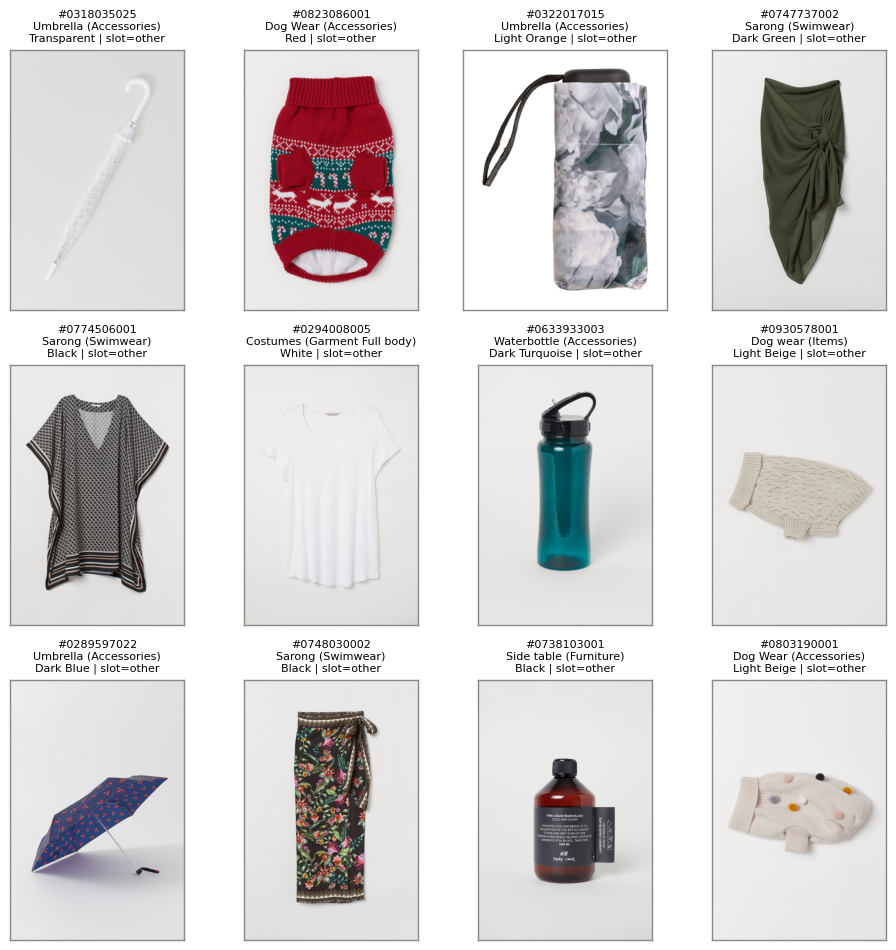

In [5]:
SLOT = "other"
N = 12
COLS = 4
SEED = None

inspector.sample_by_slot(SLOT, n=N, cols=COLS, seed=SEED)

### Chu trình recommend

Chạy từng slot dưới đây (đổi giá trị `SLOT` ở cell trên rồi rerun):

1. `top` — kiểm tra Cardigan / Bodysuit / Tailored Waistcoat có nằm trong sample không, có giống top không.
2. `outerwear` — Blazer / Coat / Jacket / Outdoor Waistcoat.
3. `bottom` — Skirt / Trousers / Shorts / Leggings.
4. `dress` — Dress / Jumpsuit / Garment Set (kiểm tra Garment Set có thực sự full-body không).
5. `shoe` — đa dạng giày.
6. `accessory` — Necklace / Bag / Belt / Hat / Watch / etc.
7. `inner` — Bra / Underwear / Socks. Confirm đây không phải item outfit chính.
8. `nightwear` — Pyjama / Robe. Confirm loại khỏi graph.
9. `swim` — Bikini / Swimsuit / Sarong.
10. `other` — items không phải fashion, đáng loại.

## Section 2 — Sample by specific product_type

Cho các PT "đáng ngờ" — ông xem ảnh thật trong dataset, quyết định slot có đúng không.

PT trong dataset (113 unique): xem [md/unique.txt](../md/unique.txt) section product_type_name.

Sample 12 items có product_type='Garment Set' (tổng 46)
slot distribution của PT này: {'nightwear': np.int64(46)}


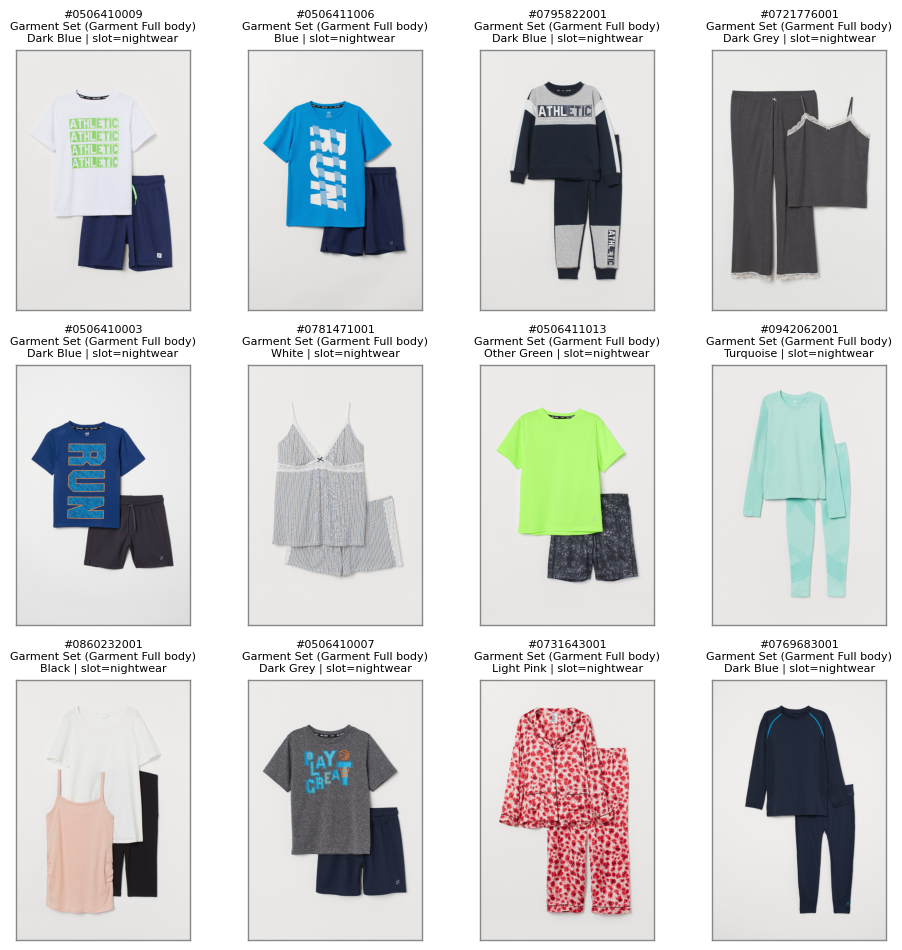

In [7]:
PRODUCT_TYPE = "Garment Set"
N = 12
COLS = 4
SEED = None

inspector.sample_by_pt(PRODUCT_TYPE, n=N, cols=COLS, seed=SEED)

### Suggested PT để check (uncertain cases)

Đổi `PRODUCT_TYPE` ở cell trên rồi rerun:

- `Cardigan` (slot top — nhưng có thể là outerwear nếu là chunky knit)
- `Bodysuit` (slot top — phần dưới là inner, có thể tranh luận)
- `Tailored Waistcoat` (slot top — H&M womenswear)
- `Garment Set` (slot dress — confirm là set full body, không phải accessory set)
- `Sarong` (slot swim — beach wrap)
- `Costumes` (slot other — Halloween costume có nên loại?)
- `Underdress` (slot inner — nhưng có thể là slip dress mặc ngoài?)
- `Long John` (slot inner — base layer mùa đông)
- `Bra` (slot inner — nhưng Sports Bra trong section H&M Sport có nên giữ?)
- Bất kỳ PT nào ông tò mò

## Section 3 — Sample pair theo slot pair

Pick một slot pair → notebook tìm pair có thật trong graph + display ảnh side-by-side. Ông xem ảnh để confirm pair này có nghĩa cho outfit không.

**ALLOWED_SLOT_PAIRS hiện tại** (kết hợp được phép):

In [8]:
for pair in sorted(ALLOWED_SLOT_PAIRS, key=lambda s: sorted(s)):
    print(" + ".join(sorted(pair)))

accessory
accessory + bottom
accessory + dress
accessory + outerwear
accessory + shoe
accessory + swim
accessory + top
bottom + outerwear
bottom + shoe
bottom + top
dress + outerwear
dress + shoe
outerwear + shoe
outerwear + top
shoe + swim
shoe + top


Sample 6 pairs với slot=(bottom,shoe):


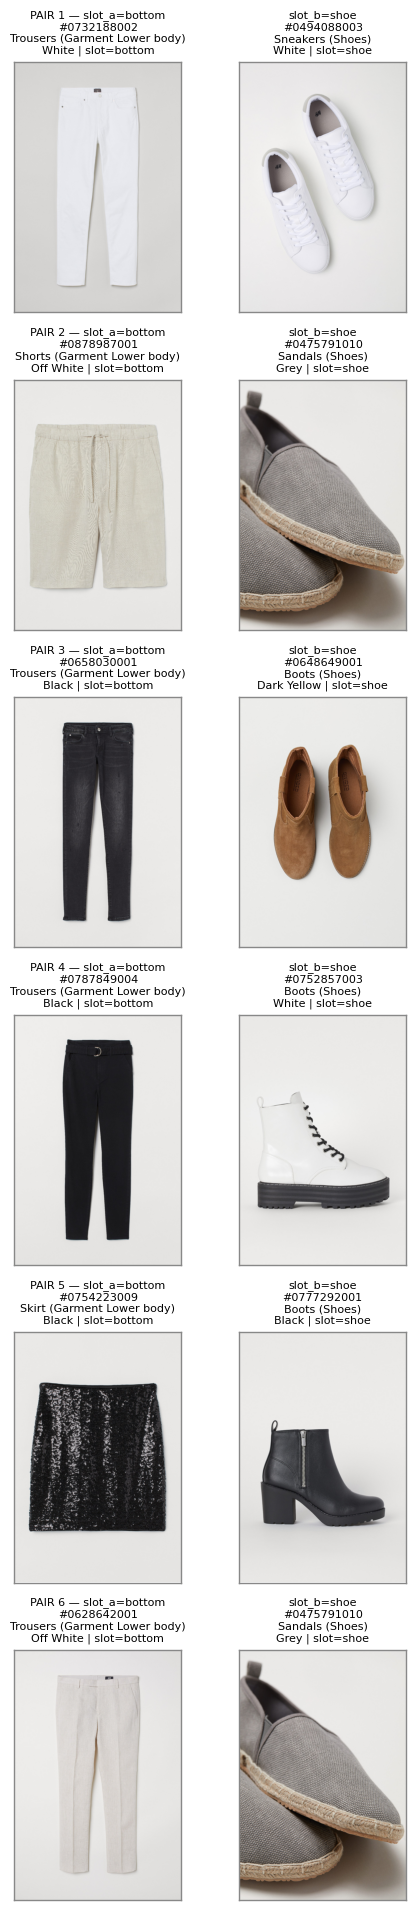

In [19]:
SLOT_A = "bottom"
SLOT_B = "shoe"
N_PAIRS = 6
SEED = None

inspector.sample_slot_pair(SLOT_A, SLOT_B, n_pairs=N_PAIRS, seed=SEED)

### Pair combinations đáng check

Đổi `SLOT_A`, `SLOT_B` ở cell trên rồi rerun:

- `top` + `bottom` — outfit cơ bản
- `top` + `outerwear` — layering
- `dress` + `outerwear` — dress + jacket
- `dress` + `shoe` — dress + footwear
- `accessory` + `accessory` — phụ kiện kết hợp (test logic mới)
- `outerwear` + `shoe` — outerwear + giày
- `swim` + `accessory` — bikini + hat/sunglasses
- `bottom` + `shoe` — bottom + giày

Có thể test slot pair FORBIDDEN để xem hệ thống có còn nhầm không (nếu code đúng → không có pair nào trong graph, sẽ in 'không tìm được pair nào'):

- `top` + `top` — should be 0 pairs
- `bottom` + `bottom` — should be 0 pairs
- `dress` + `top` — should be 0 pairs (dress là full body)
- `dress` + `bottom` — should be 0 pairs

## Section 4 — "Other" slot deep dive

Items có slot=`other` đang bị loại HOÀN TOÀN khỏi graph. Section này show ảnh sample để confirm các items này thật sự không phải fashion (vd. Furniture, Side table, Sewing kit).

Nếu ông phát hiện item nào thật ra là fashion nhưng đang ở slot=other (vd. Sarong, Costumes), note vào [Todo_human_1.md](../md/Todo_human_1.md).

Sample 16 items có slot='other' (tổng 220 items)
PT distribution trong slot: {'Unknown': np.int64(111), 'Umbrella': np.int64(29), 'Dog Wear': np.int64(20), 'Waterbottle': np.int64(19), 'Side table': np.int64(13), 'Dog wear': np.int64(7), 'Marker pen': np.int64(5), 'Costumes': np.int64(4), 'Giftbox': np.int64(3), 'Zipper head': np.int64(3), 'Stain remover spray': np.int64(2), 'Wood balls': np.int64(1), 'Sewing kit': np.int64(1), 'Washing bag': np.int64(1), 'Clothing mist': np.int64(1)}


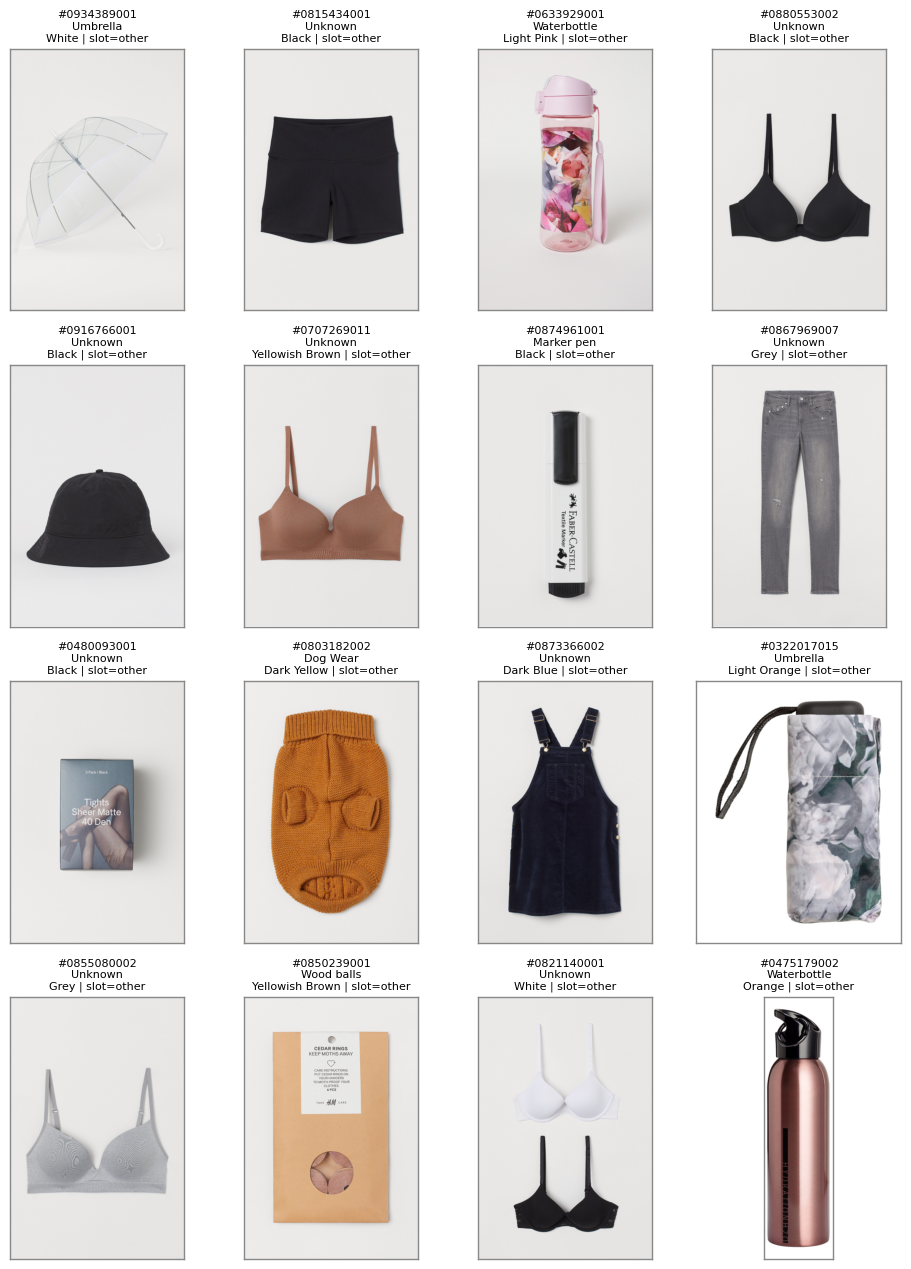

In [7]:
inspector.sample_by_slot("other", n=16, cols=4, seed=None)

In [8]:
other_subset = meta_df[meta_df["slot"] == "other"]
print(f"Tổng items slot=other: {len(other_subset):,}")
print()
print("Phân bố theo product_type_name:")
print(other_subset["product_type_name"].value_counts().to_string())

Tổng items slot=other: 220

Phân bố theo product_type_name:
product_type_name
Unknown                111
Umbrella                29
Dog Wear                20
Waterbottle             19
Side table              13
Dog wear                 7
Marker pen               5
Costumes                 4
Giftbox                  3
Zipper head              3
Stain remover spray      2
Wood balls               1
Sewing kit               1
Washing bag              1
Clothing mist            1


## Section 5 — Sửa nhanh slot mapping

Nếu ông muốn thử đổi slot của 1 PT cụ thể NGAY trong notebook (không sửa file source), dùng cell sau. Lưu ý: chỉ ảnh hưởng session hiện tại của notebook, không persist.

Để persist: sửa thẳng [src/scripts/outfit_slots.py](../src/scripts/outfit_slots.py) → tôi rebuild graph.

In [9]:
OVERRIDE_PT = "Cardigan"
NEW_SLOT = "outerwear"

meta_df.loc[meta_df["product_type_name"] == OVERRIDE_PT, "slot"] = NEW_SLOT
print(f"Override (session only): {OVERRIDE_PT} → {NEW_SLOT}")
print(f"Items ảnh hưởng: {(meta_df['product_type_name'] == OVERRIDE_PT).sum():,}")

Override (session only): Cardigan → outerwear
Items ảnh hưởng: 895


## Section 6 — Bra Sports vs Bra Lingerie (cho Todo_human_2 phần 4)

Bra hiện đang slot=inner → bị loại. Nhưng Sports Bra trong athletic context là outfit hợp lệ. Section này tách Bra theo section_name để ông quyết định:

- Bra trong section `Ladies H&M Sport` → có nên đặc cách slot=top?
- Bra trong section regular Lingerie → giữ slot=inner.

In [10]:
bra_subset = meta_df[meta_df["product_type_name"] == "Bra"]
print(f"Tổng Bra items: {len(bra_subset):,}")
print()
print("Bra phân bố theo section_name:")
print(bra_subset["section_name"].value_counts().to_string())

Tổng Bra items: 2,199

Bra phân bố theo section_name:
section_name
Womens Lingerie                   1789
Ladies H&M Sport                   275
Womens Nightwear, Socks & Tigh      47
H&M+                                28
Collaborations                      17
Kids Sports                         17
Divided Basics                      11
Special Collections                 10
Men Underwear                        3
Mama                                 2


Sample 8 'Bra' trong section='Ladies H&M Sport' (tổng 275)


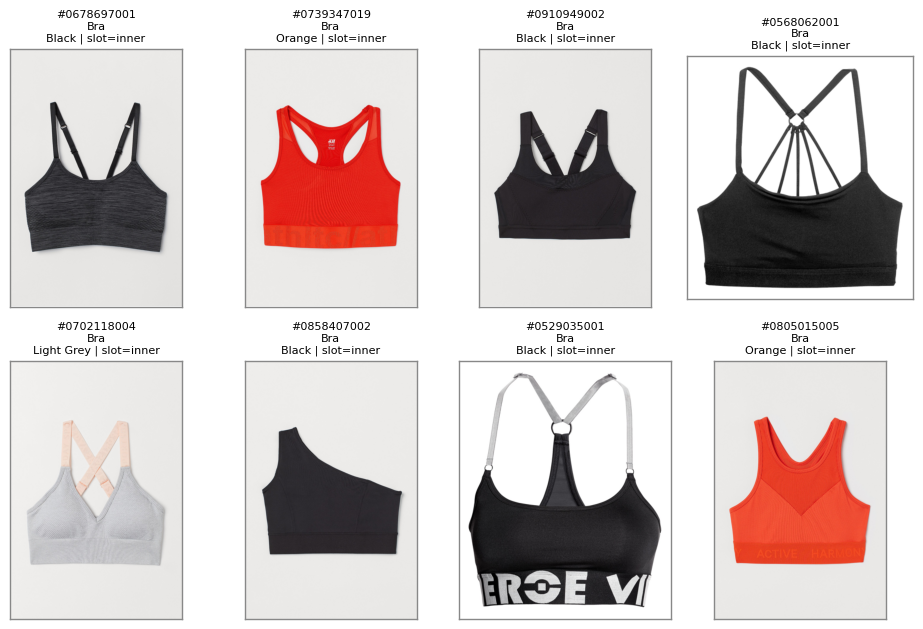

In [11]:
SECTION_FILTER = "Ladies H&M Sport"
N = 8
SEED = None

sports_bra = bra_subset[bra_subset["section_name"] == SECTION_FILTER]
if sports_bra.empty:
    print(f"không có Bra trong section '{SECTION_FILTER}'")
else:
    rng = random.Random(SEED) if SEED is not None else random.Random()
    sample = sports_bra.sample(min(N, len(sports_bra)), random_state=rng.randint(0, 2**31))
    cols = 4
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 3.2))
    axes = np.atleast_2d(axes).reshape(rows, cols)
    print(f"Sample {len(sample)} 'Bra' trong section='{SECTION_FILTER}' (tổng {len(sports_bra):,})")
    for idx, (_, row) in enumerate(sample.iterrows()):
        r, c = divmod(idx, cols)
        inspector._draw_tile(axes[r, c], row)
    for idx in range(len(sample), rows * cols):
        r, c = divmod(idx, cols)
        axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()

## Sau khi check xong

1. Nếu thấy slot nào sai → sửa thẳng [src/scripts/outfit_slots.py](../src/scripts/outfit_slots.py) → báo tôi rebuild graph.
2. Nếu thấy slot pair (vd. dress+top) cần thay đổi → sửa `ALLOWED_SLOT_PAIRS` trong outfit_slots.py.
3. Nếu Sports Bra cần đặc cách → quyết định Option B trong [Todo_human_2.md](../md/Todo_human_2.md) phần 4, tôi sẽ implement (cần thêm logic check section_name khi assign slot).